In [1]:
from magma_rsam import RSAM, PlotRsam
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import pandas as pd

In [2]:
start_date='2024-01-01'
end_date='2024-04-19'

In [3]:
rsam = RSAM(
    seismic_dir="G:\\Output1\\Converted\\SDS",
    station="RUA3",
    start_date=start_date,
    end_date=end_date,
)

In [4]:
# rsam.apply_filter(freq_min=5.0, freq_max=18.0)

In [5]:
rsam.run()

⌚ 2024-01-01 Calculating for VG.RUA3.00.EHZ
💾 Saved to D:\Project\magma-rsam\output\rsam\VG.RUA3.00.EHZ\not_filtered\10min\2024-01-01.csv
⌚ 2024-01-02 Calculating for VG.RUA3.00.EHZ
💾 Saved to D:\Project\magma-rsam\output\rsam\VG.RUA3.00.EHZ\not_filtered\10min\2024-01-02.csv
⌚ 2024-01-03 Calculating for VG.RUA3.00.EHZ
💾 Saved to D:\Project\magma-rsam\output\rsam\VG.RUA3.00.EHZ\not_filtered\10min\2024-01-03.csv
⌚ 2024-01-04 Calculating for VG.RUA3.00.EHZ
💾 Saved to D:\Project\magma-rsam\output\rsam\VG.RUA3.00.EHZ\not_filtered\10min\2024-01-04.csv
⌚ 2024-01-05 Calculating for VG.RUA3.00.EHZ
💾 Saved to D:\Project\magma-rsam\output\rsam\VG.RUA3.00.EHZ\not_filtered\10min\2024-01-05.csv
⌚ 2024-01-06 Calculating for VG.RUA3.00.EHZ
💾 Saved to D:\Project\magma-rsam\output\rsam\VG.RUA3.00.EHZ\not_filtered\10min\2024-01-06.csv
⌚ 2024-01-07 Calculating for VG.RUA3.00.EHZ
💾 Saved to D:\Project\magma-rsam\output\rsam\VG.RUA3.00.EHZ\not_filtered\10min\2024-01-07.csv
⌚ 2024-01-08 Calculating for VG.RU

In [6]:
# rsam.files

In [8]:
plot_rsam = PlotRsam(
    station="RUA3",
    channel="EHZ",
    start_date=start_date,
    end_date=end_date,
    # freq_min=5.0,
    # freq_max=18.0
)

ℹ️ Start Date: 2024-01-01
ℹ️ End Date: 2024-04-19
ℹ️ Station: RUA3
ℹ️ Channel: EHZ
ℹ️ Network: VG
ℹ️ Location: 00
ℹ️ Freq Min: None
ℹ️ Freq Max: None
ℹ️ Resample: 10min


In [9]:
plot_rsam.run()

✅ Combined CSV saved to : D:\Project\magma-rsam\output\rsam\VG.RUA3.00.EHZ\not_filtered\combined_2024-01-01_2024-04-19_10min_not_filtered.csv


,min,mean,max,median,std
datetime,,,,,
2024-01-01 00:00:00,0.106916,15.739977,77.893084,13.893084,11.303598
2024-01-01 00:10:00,0.106916,15.227545,76.893084,13.106916,10.999594
2024-01-01 00:20:00,0.106916,17.813886,155.893084,14.893084,13.846629
2024-01-01 00:30:00,0.106916,17.047754,190.893084,14.893084,12.938930
2024-01-01 00:40:00,0.106916,21.916051,453.893084,16.106916,23.367727
...,...,...,...,...,...
2024-04-15 20:10:00,0.198035,32.068852,822.801965,21.801965,41.140537
2024-04-15 20:20:00,0.198035,52.743434,1514.198035,34.801965,67.594314
2024-04-15 20:30:00,0.198035,43.336000,452.801965,32.801965,39.650892


In [10]:
df = plot_rsam.df

In [11]:
datetime_index: pd.DatetimeIndex = pd.date_range(start=start_date, end=end_date, freq='10min')

In [12]:
df = df.reindex(datetime_index)

In [13]:
df['mean_24h'] = df['mean'].rolling('1d', center=True).median()

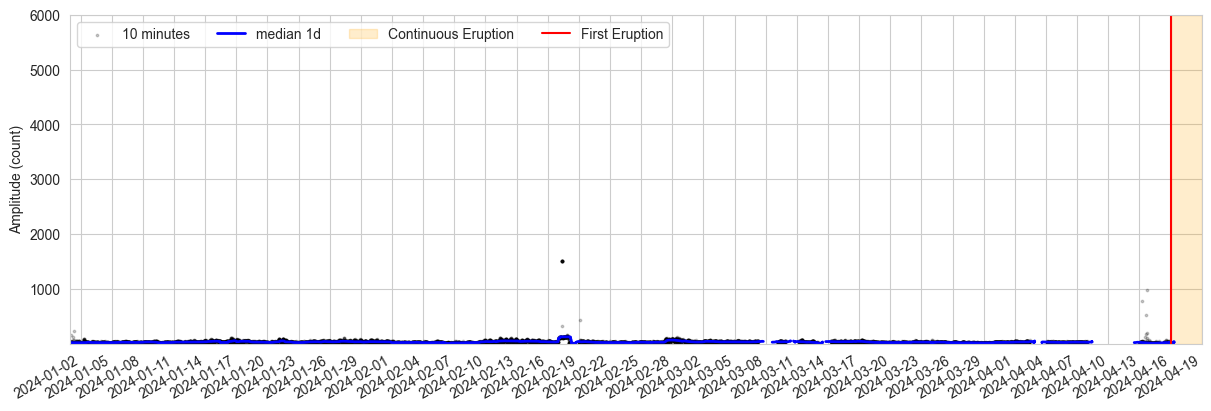

In [18]:
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(12, 4),
                        layout="constrained", sharex=True)

axs.scatter(df.index, df['mean'], c='k', alpha=0.2, s=3, label='10 minutes')
axs.plot(df.index, df['mean_24h'], c='blue', label='median 1d', alpha=1, lw=2)
axs.set_ylabel('Amplitude (count)')

axs.xaxis.set_major_locator(mdates.DayLocator(interval=3))
axs.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
axs.set_ylim(1, 6000)
# axs.set_yscale('log')
axs.set_xlim(df.first_valid_index(), datetime.strptime("2024-04-19", '%Y-%m-%d'))

axs.axvspan("2024-04-16", "2024-04-19", alpha=0.2,
             color='orange', label='Continuous Eruption')

axs.axvline(datetime.strptime("2024-04-16", '%Y-%m-%d'),
            color='red', label='First Eruption')

for label in axs.get_xticklabels(which='major'):
    label.set(rotation=30, horizontalalignment='right')
    
axs.legend(loc='upper left', fontsize='10', ncol=4)

fig.savefig('rsam_bandung.png')

In [ ]:
continuous_events = [
    {
        'name': 'Eruption',
        'dates': ['2024-04-16', '2024-04-16'],
        'color': 'orange'
    }
]

In [ ]:
events = [
    {
        'name': 'Level II',
        'dates': ['2024-04-16', '2024-04-18'],
        'color': 'orange'
    }
]

In [ ]:
continuous_events = continuous_events + events

In [ ]:
continuous_events